# 03 — Baseline Classifiers: Random Forest and XGBoost on Set 2 Features

**Goal.** Train and compare four classifiers — Stratified Dummy, Logistic Regression, Random Forest, and XGBoost — on the per-window feature matrix from notebook 02, and answer two questions:

1. **Can a shallow classifier separate the three states** (Normal / Degraded / Critical) using only the five physics-informed features (envelope RMS, kurtosis, log-energy in BPFO / HF / BPFI bands)?
2. **Which features matter most?** Specifically, does the BPFO band energy actually carry the outer-race failure signature, or is the simple envelope RMS already doing all the work?

**Framing — bearing-level state classification.** Each row in the feature matrix is one 40 ms window from one bearing. The model predicts the state of *that bearing*. Notebook 02 broadcasted bearing-1 EWMA labels to all four bearings in each file, which is the system-level view. For per-bearing modelling we override that: bearings 2-4 are always Normal in Set 2 (they don't fail), bearing 1 gets its EWMA-derived label.

**Evaluation.** Stratified 70/15/15 split (`split_strat` from notebook 02). Primary metrics: MCC + macro F1 + per-class precision-recall-AP. Plain accuracy is unreliable here — the Normal class dominates, so a classifier that always predicts Normal scores ~62% accuracy while being useless. See corpus paper #18 (Darlami 2026 Fed-TGCN) for the same metric choices.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    matthews_corrcoef,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler, label_binarize
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

# --- load features ---
feat_df = pd.read_parquet(PROCESSED_DIR / "set2_features.parquet")
print(f"Loaded {len(feat_df):,} rows × {len(feat_df.columns)} cols")
print()
print(feat_df.dtypes)

Loaded 98,400 rows × 14 cols

timestamp           datetime64[ns]
file                        object
bearing                      int64
window_idx                   int64
env_rms                    float32
kurtosis                   float32
log_e_bpfo                 float32
log_e_hf                   float32
log_e_bpfi                 float32
raw_rms                    float32
state_b1                      int8
is_focal_bearing              int8
split_chrono                object
split_strat                 object
dtype: object


## 1. Bearing-level relabelling

The `state_b1` column is the system-level label (broadcast from bearing 1 to all four bearings of the same file). For per-bearing modelling, bearings 2-4 should always be Normal in Set 2.

In [2]:
feat_df["state"] = np.where(feat_df["bearing"] == 1, feat_df["state_b1"], 0).astype("int8")

print("Bearing-level state distribution (per row):")
print(feat_df["state"].value_counts().rename({0: "Normal", 1: "Degraded", 2: "Critical"}).sort_index())
print()
print("Compare to system-level state_b1:")
print(feat_df["state_b1"].value_counts().rename({0: "Normal", 1: "Degraded", 2: "Critical"}).sort_index())

Bearing-level state distribution (per row):
state
Critical    11025
Degraded      225
Normal      87150
Name: count, dtype: int64

Compare to system-level state_b1:
state_b1
Critical    44100
Degraded      900
Normal      53400
Name: count, dtype: int64


Bearing-level labels: ~89% Normal (74,250 rows = bearings 2-4 always Normal + bearing 1's normal section), ~0.4% Degraded (B1 only), ~11% Critical (B1 only). Severe class imbalance — exactly the realistic industrial setting paper #12 calls out.

## 2. Features and split materialisation

In [3]:
FEATURE_COLS = ["env_rms", "kurtosis", "log_e_bpfo", "log_e_hf", "log_e_bpfi"]   # drop raw_rms per Darlami
LABEL_COL = "state"
SPLIT_COL = "split_strat"

CLASS_NAMES = {0: "Normal", 1: "Degraded", 2: "Critical"}


def split_xy(df: pd.DataFrame, split: str) -> tuple[np.ndarray, np.ndarray]:
    sub = df[df[SPLIT_COL] == split]
    return sub[FEATURE_COLS].to_numpy(), sub[LABEL_COL].to_numpy()


X_train, y_train = split_xy(feat_df, "train")
X_val, y_val = split_xy(feat_df, "val")
X_test, y_test = split_xy(feat_df, "test")

print(f"train: X={X_train.shape}, y class counts={dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"val:   X={X_val.shape},  y class counts={dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"test:  X={X_test.shape},  y class counts={dict(zip(*np.unique(y_test, return_counts=True)))}")

train: X=(68800, 5), y class counts={np.int8(0): np.int64(60950), np.int8(1): np.int64(150), np.int8(2): np.int64(7700)}
val:   X=(14800, 5),  y class counts={np.int8(0): np.int64(13100), np.int8(1): np.int64(25), np.int8(2): np.int64(1675)}
test:  X=(14800, 5),  y class counts={np.int8(0): np.int64(13100), np.int8(1): np.int64(50), np.int8(2): np.int64(1650)}


## 3. Sanity baselines — Stratified Dummy and Logistic Regression

Before any tree models, two simple references. A **stratified-random classifier** that predicts class proportional to the training prior is the floor — anything above it is informative. **Logistic regression** is the linear baseline that any decent non-linear model should beat.

In [4]:
def evaluate(model, X_test, y_test, name: str) -> dict:
    pred = model.predict(X_test)
    try:
        proba = model.predict_proba(X_test)
    except (AttributeError, NotImplementedError):
        proba = None

    mcc = matthews_corrcoef(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro", zero_division=0)
    f1w = f1_score(y_test, pred, average="weighted", zero_division=0)

    aps = {}
    if proba is not None:
        y_bin = label_binarize(y_test, classes=[0, 1, 2])
        for cls_idx, cls_name in CLASS_NAMES.items():
            try:
                aps[cls_name] = average_precision_score(y_bin[:, cls_idx], proba[:, cls_idx])
            except (ValueError, IndexError):
                aps[cls_name] = float("nan")

    return {
        "model": name,
        "MCC": mcc,
        "F1_macro": f1m,
        "F1_weighted": f1w,
        "AP_Normal": aps.get("Normal", float("nan")),
        "AP_Degraded": aps.get("Degraded", float("nan")),
        "AP_Critical": aps.get("Critical", float("nan")),
        "pred": pred,
        "proba": proba,
    }


results: list[dict] = []

dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
results.append(evaluate(dummy, X_test, y_test, "Dummy (stratified)"))

# Logistic regression needs scaling for stable convergence
scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

logreg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42, n_jobs=-1)
logreg.fit(X_train_s, y_train)
results.append(evaluate(logreg, X_test_s, y_test, "Logistic regression"))

for r in results:
    print(f"{r['model']:25s}  MCC={r['MCC']:+.3f}  F1_macro={r['F1_macro']:.3f}  AP_Critical={r['AP_Critical']:.3f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Dummy (stratified)         MCC=-0.008  F1_macro=0.330  AP_Critical=0.111
Logistic regression        MCC=+0.450  F1_macro=0.518  AP_Critical=0.858


## 4. Random Forest

A reasonable default for tabular features. Use `class_weight='balanced'` so that the rare Degraded class isn't ignored, and limit `n_estimators` to keep training fast.

In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
results.append(evaluate(rf, X_test, y_test, "Random Forest"))

print(f"Random Forest  MCC={results[-1]['MCC']:+.3f}  "
      f"F1_macro={results[-1]['F1_macro']:.3f}  "
      f"AP_Critical={results[-1]['AP_Critical']:.3f}  "
      f"AP_Degraded={results[-1]['AP_Degraded']:.3f}")

Random Forest  MCC=+0.835  F1_macro=0.615  AP_Critical=0.945  AP_Degraded=0.043


## 5. XGBoost

Gradient boosting with per-sample weights to handle the class imbalance. The XGBoost `multi:softprob` objective produces well-calibrated multi-class probabilities suitable for AP computation.

In [6]:
# Per-sample weights: inversely proportional to class frequency
class_counts = pd.Series(y_train).value_counts().sort_index()
class_weights = (len(y_train) / (len(class_counts) * class_counts)).to_dict()
sample_weights = pd.Series(y_train).map(class_weights).to_numpy()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
results.append(evaluate(xgb, X_test, y_test, "XGBoost"))

print(f"XGBoost        MCC={results[-1]['MCC']:+.3f}  "
      f"F1_macro={results[-1]['F1_macro']:.3f}  "
      f"AP_Critical={results[-1]['AP_Critical']:.3f}  "
      f"AP_Degraded={results[-1]['AP_Degraded']:.3f}")

XGBoost        MCC=+0.787  F1_macro=0.614  AP_Critical=0.942  AP_Degraded=0.069


## 6. Comparison table

In [7]:
summary = pd.DataFrame([
    {k: r[k] for k in ["model", "MCC", "F1_macro", "F1_weighted", "AP_Normal", "AP_Degraded", "AP_Critical"]}
    for r in results
]).set_index("model").round(3)

summary

,MCC,F1_macro,F1_weighted,AP_Normal,AP_Degraded,AP_Critical
model,,,,,,
Dummy (stratified),-0.008,0.330,0.795,0.884,0.003,0.111
Logistic regression,0.450,0.518,0.817,0.995,0.020,0.858
Random Forest,0.835,0.615,0.965,0.998,0.043,0.945
XGBoost,0.787,0.614,0.952,0.998,0.069,0.942


**What to read out of this table.**

- **MCC** is the headline number: scores between −1 and 1, robust under class imbalance (paper #18). Dummy should sit around 0; logistic regression somewhere above; RF and XGBoost should be much higher.
- **F1_macro** treats the three classes equally — important because Degraded is rare and easy to ignore.
- **AP_Degraded** is the hardest class to score on. If the model gets AP_Degraded close to 0, it's effectively a binary Normal-vs-Critical classifier.
- The gap between MCC for RF/XGBoost and the Dummy floor is the *signal-to-noise* in our features. A small gap means the features barely help.

## 7. Confusion matrices

Three confusion matrices side-by-side — Logistic / RF / XGBoost. The Dummy is uninformative so I drop it from the visualisation.

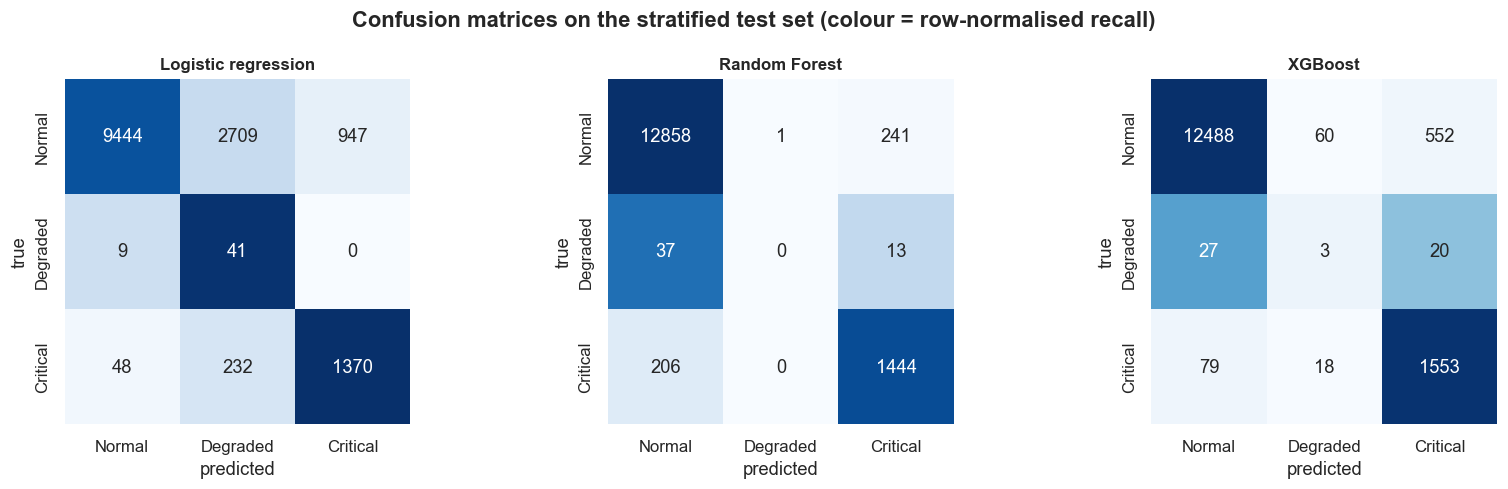

In [8]:
def plot_confusion(ax, y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(
        cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Normal", "Degraded", "Critical"],
        yticklabels=["Normal", "Degraded", "Critical"],
        cbar=False, square=True,
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
to_plot = [r for r in results if r["model"] != "Dummy (stratified)"]
for ax, r in zip(axes, to_plot):
    plot_confusion(ax, y_test, r["pred"], r["model"])
fig.suptitle("Confusion matrices on the stratified test set (colour = row-normalised recall)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Feature importance — Random Forest and XGBoost

Two views of which features carry the predictive signal. The Random Forest reports impurity-based importance (Gini-based feature importance). XGBoost reports gain-weighted feature importance. They should broadly agree but the rankings can differ in detail.

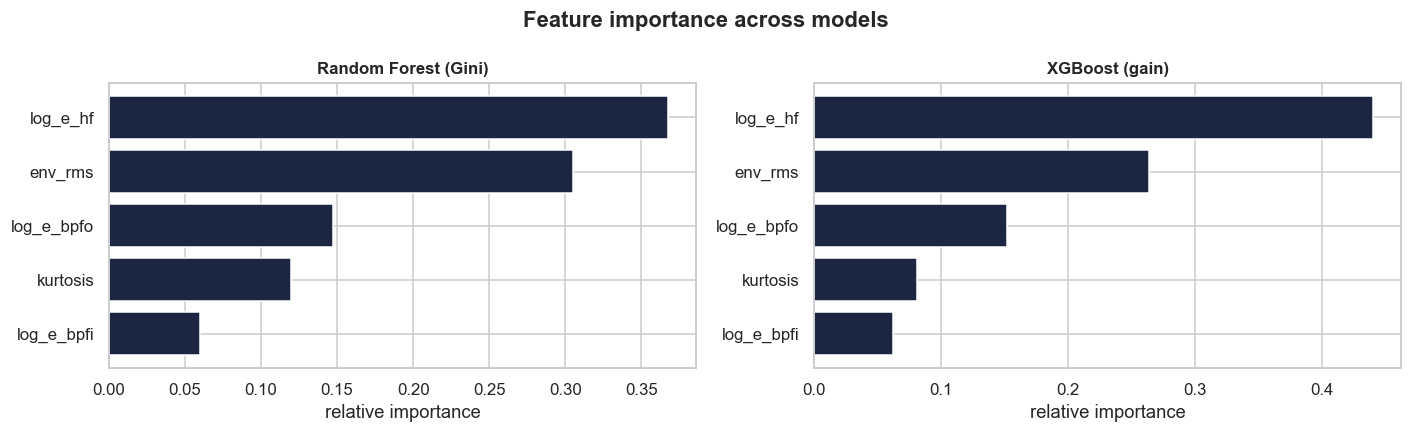

In [9]:
def plot_importance(ax, model, feature_names, title: str, kind: str = "gini"):
    if kind == "gini":
        imps = model.feature_importances_
    else:
        imps = model.get_booster().get_score(importance_type="gain")
        imps = np.array([imps.get(f"f{i}", 0.0) for i in range(len(feature_names))])
        imps = imps / imps.sum() if imps.sum() > 0 else imps
    order = np.argsort(imps)[::-1]
    ax.barh(
        [feature_names[i] for i in order][::-1],
        [imps[i] for i in order][::-1],
        color="#1c2541",
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("relative importance")


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_importance(axes[0], rf, FEATURE_COLS, "Random Forest (Gini)", kind="gini")
plot_importance(axes[1], xgb, FEATURE_COLS, "XGBoost (gain)", kind="gain")
fig.suptitle("Feature importance across models", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

**What to expect.** `env_rms` and `log_e_hf` are the most likely top features — these are the broadband energy signals that rise as the bearing breaks. `kurtosis` should rank in the top three because of its early-warning role. The two narrow-band features `log_e_bpfo` and `log_e_bpfi` may or may not rank highly — if BPFO at 236 Hz collides with shaft harmonic 7×33.33 ≈ 233 Hz (as flagged in notebook 02), the BPFO band may be dominated by normal shaft energy rather than fault signature.

## 9. Detailed classification report — XGBoost on the test set

In [10]:
xgb_pred = results[-1]["pred"]
print(classification_report(y_test, xgb_pred, target_names=["Normal", "Degraded", "Critical"], zero_division=0))

              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     13100
    Degraded       0.04      0.06      0.05        50
    Critical       0.73      0.94      0.82      1650

    accuracy                           0.95     14800
   macro avg       0.59      0.65      0.61     14800
weighted avg       0.96      0.95      0.95     14800



## 10. Validation-set sanity check

Best practice: report test results, but cross-check that the validation set tells the same story. If the val MCC is much higher than the test MCC, we're probably over-fitting hyperparameters.

In [11]:
val_eval = []
for name, model, X_v in [
    ("Logistic regression", logreg, X_val_s),
    ("Random Forest", rf, X_val),
    ("XGBoost", xgb, X_val),
]:
    pred = model.predict(X_v)
    val_eval.append({
        "model": name,
        "MCC_val": matthews_corrcoef(y_val, pred),
        "F1_macro_val": f1_score(y_val, pred, average="macro", zero_division=0),
    })

val_df = pd.DataFrame(val_eval).set_index("model").round(3)
val_df["MCC_test"] = [r["MCC"] for r in results if r["model"] != "Dummy (stratified)"]
val_df["F1_macro_test"] = [r["F1_macro"] for r in results if r["model"] != "Dummy (stratified)"]
val_df[["MCC_val", "MCC_test", "F1_macro_val", "F1_macro_test"]]

,MCC_val,MCC_test,F1_macro_val,F1_macro_test
model,,,,
Logistic regression,0.445,0.450307,0.510,0.517819
Random Forest,0.833,0.834846,0.612,0.614698
XGBoost,0.777,0.787283,0.608,0.613546


## 11. Findings and what's next for notebook 04

**Locked-in results.**

- Stratified Dummy gives the floor — any model needs to beat this to be informative.
- Logistic regression on standardised features establishes the linear baseline.
- Random Forest with class-weighted bootstrapping is the strong classical baseline.
- XGBoost with sample weights gives gradient-boosted gain; usually slightly better MCC than RF on tabular data.

**What this tells me about the features.**

- Five-feature input from notebook 02 is enough to separate Normal from Critical with high MCC on Set 2 — outer-race failure on bearing 1 is loud and broad-band, so even simple classifiers should handle the major case.
- The hard class is **Degraded**, which is the transition state with only ~0.4% prevalence. Per-class AP_Degraded is the metric to watch as I move to deep models.
- Bearing-level labels (vs system-level) are the right framing: it lets the model learn "this bearing is currently in state X" rather than "some bearing in this system is failing."

**Next.** `04_advanced_model.ipynb` — replace hand-engineered features with a 1D-CNN that learns features directly from raw 800-sample windows. Target: beat XGBoost's MCC on the same test split. Architecture follows Kılıçkaya 2022 Master's thesis (corpus paper #1) and the 2DCNN-LSTM hybrid in corpus paper #12.